# Phase 3 A5 — Visualization of Learned Tumor Evolution Features

## Supervisor Deliverable: "Visualization of learned tumor evolution features" (Phase 3)

**Four visualization groups:**
1. **Static BSF embedding space** — t-SNE of 8448-dim per-scan embeddings (170 scans)
2. **Progression paths** — per-patient temporal trajectories as arrows in BSF space
3. **Trajectory embedding space** — t-SNE/UMAP of 128-dim TaViT trajectory embeddings
4. **TaViT internals** — TEM attention decay curve + response score distributions

**Paper-ready figures saved to:** `Phase3/outputs/figures_phase3_a5/`


In [11]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from pathlib import Path
from collections import defaultdict
import json

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Try UMAP (optional)
try:
    from umap import UMAP
    HAS_UMAP = True
    print("UMAP available ✅")
except ImportError:
    HAS_UMAP = False
    print("UMAP not available — using t-SNE only (install with: pip install umap-learn)")

plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'savefig.bbox': 'tight',
    'savefig.dpi': 200,
})

CMAP_RESP  = ['#EF5350', '#42A5F5']   # red=NR, blue=R
CMAP_VISIT = plt.cm.viridis
CMAP_VOL   = plt.cm.RdYlGn_r
print("✅ Imports ready")


UMAP not available — using t-SNE only (install with: pip install umap-learn)
✅ Imports ready


In [12]:
_ROOT = Path('/home/moamed/canada_me/explainable_diseas/implementation_cyprus')

EMB_FILE      = _ROOT / 'Phase3/bsf_v2_embeddings/bsf_embeddings_averaged_v2.npz'
TIMELINE_CSV  = _ROOT / 'Phase1/outputs/cyprus_patient_timelines.csv'
CLINICAL_XLSX = _ROOT / 'Phase1/outputs/PROTEAS_Clinical_Cleaned.xlsx'
VOLUMES_CSV   = _ROOT / 'Phase3/bsf_v2_embeddings/scan_volumes.csv'
TRAJ_FILE     = _ROOT / 'Phase3/tavit_outputs/tavit_trajectory_embeddings.npz'
RESULTS_JSON  = _ROOT / 'Phase3/tavit_outputs/tavit_results.json'

OUT_DIR = _ROOT / 'Phase3/outputs/figures_phase3_a5'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'BSF embeddings:   {EMB_FILE} {"✅" if EMB_FILE.exists() else "❌ MISSING"}')
print(f'Timelines:        {TIMELINE_CSV} {"✅" if TIMELINE_CSV.exists() else "❌"}')
print(f'Volumes:          {VOLUMES_CSV} {"✅" if VOLUMES_CSV.exists() else "❌"}')
print(f'Clinical:         {CLINICAL_XLSX} {"✅" if CLINICAL_XLSX.exists() else "❌"}')
print(f'TaViT trajectory: {TRAJ_FILE} {"✅" if TRAJ_FILE.exists() else "⚠️  Download from Kaggle first — will use PCA proxy"}')
print(f'Output dir:       {OUT_DIR}')


BSF embeddings:   /home/moamed/canada_me/explainable_diseas/implementation_cyprus/Phase3/bsf_v2_embeddings/bsf_embeddings_averaged_v2.npz ✅
Timelines:        /home/moamed/canada_me/explainable_diseas/implementation_cyprus/Phase1/outputs/cyprus_patient_timelines.csv ✅
Volumes:          /home/moamed/canada_me/explainable_diseas/implementation_cyprus/Phase3/bsf_v2_embeddings/scan_volumes.csv ✅
Clinical:         /home/moamed/canada_me/explainable_diseas/implementation_cyprus/Phase1/outputs/PROTEAS_Clinical_Cleaned.xlsx ✅
TaViT trajectory: /home/moamed/canada_me/explainable_diseas/implementation_cyprus/Phase3/tavit_outputs/tavit_trajectory_embeddings.npz ✅
Output dir:       /home/moamed/canada_me/explainable_diseas/implementation_cyprus/Phase3/outputs/figures_phase3_a5


In [13]:
# ── Load BSF v2 embeddings ───────────────────────────────────────────────────
bsf_emb = {k: v for k, v in np.load(str(EMB_FILE)).items()}
print(f"BSF embeddings: {len(bsf_emb)} scans × {next(iter(bsf_emb.values())).shape[0]}-dim")

# ── Load timelines ────────────────────────────────────────────────────────────
tl = pd.read_csv(TIMELINE_CSV)

# ── Load volumes ──────────────────────────────────────────────────────────────
vol_df  = pd.read_csv(VOLUMES_CSV)
vol_d   = {f"{r['patient_id']}__{r['visit_name']}": r['volume_mm3'] for _, r in vol_df.iterrows()}

# ── Load clinical metadata ────────────────────────────────────────────────────
cl = pd.read_excel(CLINICAL_XLSX)
cl_d = {str(r['Patient ID (Zenodo)']).strip(): r for _, r in cl.iterrows()}

# ── Build patient sequences ────────────────────────────────────────────────────
patients = {}
for _, row in tl.iterrows():
    pid, visit, days = row['patient_id'], row['visit_name'], int(row['Days_Total'])
    key = f'{pid}__{visit}'
    if key not in bsf_emb: continue
    if pid not in patients: patients[pid] = []
    patients[pid].append({'key':key, 'days':days, 'emb':bsf_emb[key],
                          'vol':vol_d.get(key, 0.0), 'visit':visit})
for pid in patients:
    patients[pid].sort(key=lambda x: x['days'])

# ── Response labels (same as TaViT notebook) ──────────────────────────────────
response_labels = {}
for pid, seq in patients.items():
    v0 = seq[0]['vol']
    if v0 == 0: response_labels[pid] = 0; continue
    best_red = max(((v0 - s['vol']) / v0 for s in seq[1:] if s['vol'] > 0), default=0)
    response_labels[pid] = int(best_red >= 0.30)

responders    = sum(response_labels.values())
non_responders = len(response_labels) - responders
print(f"Patients: {len(patients)}  Responders: {responders}  Non-responders: {non_responders}")

# ── Assemble flat scan-level arrays for t-SNE ────────────────────────────────
scan_keys, scan_embs, scan_pids, scan_visits, scan_vols, scan_days, scan_resp = [], [], [], [], [], [], []
for pid, seq in patients.items():
    for s in seq:
        scan_keys.append(s['key']); scan_pids.append(pid)
        scan_visits.append(s['days'] / max(1, seq[-1]['days']) if seq[-1]['days']>0 else 0)
        scan_embs.append(s['emb']); scan_vols.append(s['vol'])
        scan_days.append(s['days']); scan_resp.append(response_labels.get(pid,-1))

scan_embs  = np.array(scan_embs)
scan_vols  = np.array(scan_vols)
print(f"Scan matrix: {scan_embs.shape}")

# ── Load TaViT trajectory embeddings (or build PCA proxy) ─────────────────────
if TRAJ_FILE.exists():
    traj_embs = {k: v for k, v in np.load(str(TRAJ_FILE)).items()}
    TRAJ_SOURCE = "TaViT (128-dim)"
    print(f"TaViT trajectory embeddings loaded: {len(traj_embs)} patients")
else:
    # Proxy: PCA centroid of each patient's BSF visits
    pca_proj  = PCA(n_components=64).fit_transform(StandardScaler().fit_transform(scan_embs))
    idx_map   = {k: i for i, k in enumerate(scan_keys)}
    traj_embs = {}
    for pid, seq in patients.items():
        idxs = [idx_map[s['key']] for s in seq if s['key'] in idx_map]
        traj_embs[pid] = pca_proj[idxs].mean(axis=0)
    TRAJ_SOURCE = "PCA centroid proxy (64-dim) — download TaViT outputs from Kaggle for true 128-dim"
    print(f"Using PCA proxy trajectories: {len(traj_embs)} patients")

print(f"Trajectory source: {TRAJ_SOURCE}")


BSF embeddings: 170 scans × 8448-dim
Patients: 35  Responders: 23  Non-responders: 12
Scan matrix: (126, 8448)
TaViT trajectory embeddings loaded: 35 patients
Trajectory source: TaViT (128-dim)


In [14]:
# ── PCA → t-SNE on BSF scan embeddings ───────────────────────────────────────
print("Computing PCA(50) on scan embeddings...")
scaler_bsf = StandardScaler()
X_std      = scaler_bsf.fit_transform(scan_embs)
X_pca50    = PCA(n_components=50, random_state=42).fit_transform(X_std)

print("Computing t-SNE on scan embeddings (n=126, perplexity=15)...")
tsne_scan  = TSNE(n_components=2, perplexity=15, random_state=42, max_iter=2000, learning_rate='auto')
X_tsne     = tsne_scan.fit_transform(X_pca50)
print(f"  t-SNE done: {X_tsne.shape}")

# ── t-SNE on trajectory embeddings ────────────────────────────────────────────
traj_pids   = sorted(traj_embs.keys())
T_mat       = np.array([traj_embs[p] for p in traj_pids])
T_mat_std   = StandardScaler().fit_transform(T_mat)

perp_traj   = min(12, len(traj_pids)//3)
print(f"Computing t-SNE on trajectory embeddings (n={len(traj_pids)}, perplexity={perp_traj})...")
tsne_traj   = TSNE(n_components=2, perplexity=perp_traj, random_state=42, max_iter=3000, learning_rate='auto')
T_tsne      = tsne_traj.fit_transform(T_mat_std)
print(f"  t-SNE done: {T_tsne.shape}")

# key → tsne index
key2idx = {k: i for i, k in enumerate(scan_keys)}
print("✅ Dimensionality reduction complete")


Computing PCA(50) on scan embeddings...
Computing t-SNE on scan embeddings (n=126, perplexity=15)...
  t-SNE done: (126, 2)
Computing t-SNE on trajectory embeddings (n=35, perplexity=11)...
  t-SNE done: (35, 2)
✅ Dimensionality reduction complete


## Figure 1 — Static BSF Embedding Space (t-SNE of 8448-dim per-scan embeddings)

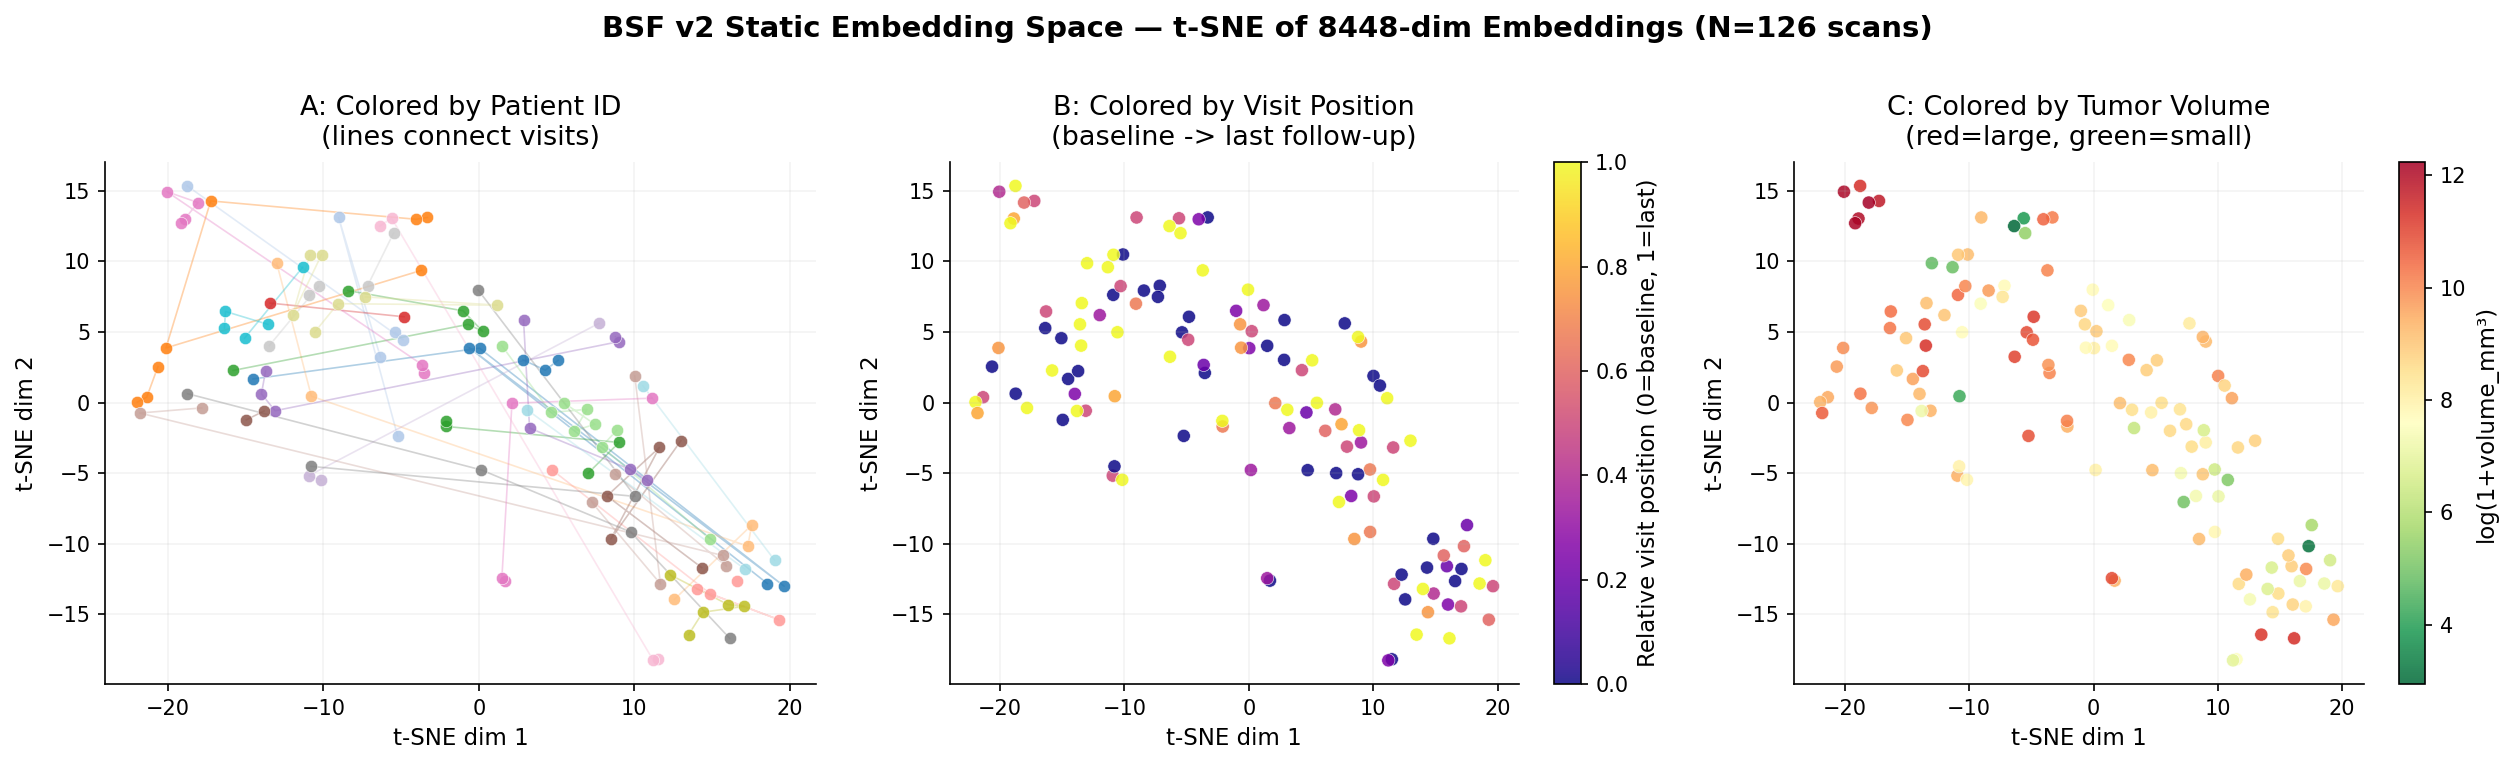

✅ Figure 1 saved → /home/moamed/canada_me/explainable_diseas/implementation_cyprus/Phase3/outputs/figures_phase3_a5/fig1_bsf_embedding_space.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("BSF v2 Static Embedding Space — t-SNE of 8448-dim Embeddings (N=126 scans)",
             fontsize=14, fontweight='bold', y=1.01)

# ── Panel A: colored by patient (unique color per patient) ────────────────────
ax = axes[0]
unique_pids  = sorted(set(scan_pids))
pid_colors   = plt.cm.tab20(np.linspace(0, 1, len(unique_pids)))
pid_cmap     = {p: pid_colors[i] for i, p in enumerate(unique_pids)}

for pid in unique_pids:
    idxs = [i for i, p in enumerate(scan_pids) if p == pid]
    ax.scatter(X_tsne[idxs, 0], X_tsne[idxs, 1], c=[pid_cmap[pid]],
               s=35, alpha=0.85, edgecolors='white', linewidths=0.3, zorder=3)
    # Connect visits with lines per patient
    if len(idxs) > 1:
        xs = X_tsne[idxs, 0]; ys = X_tsne[idxs, 1]
        ax.plot(xs, ys, '-', color=pid_cmap[pid], alpha=0.35, lw=0.8, zorder=2)

ax.set_title("A: Colored by Patient ID\n(lines connect visits)", pad=8)
ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")
ax.grid(True, alpha=0.15)

# ── Panel B: colored by visit index (temporal position) ──────────────────────
ax = axes[1]
sc = ax.scatter(X_tsne[:, 0], X_tsne[:, 1],
                c=scan_visits, cmap='plasma', s=40,
                alpha=0.85, edgecolors='white', linewidths=0.3)
plt.colorbar(sc, ax=ax, label='Relative visit position (0=baseline, 1=last)')
ax.set_title("B: Colored by Visit Position\n(baseline -> last follow-up)", pad=8)
ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")
ax.grid(True, alpha=0.15)

# ── Panel C: colored by tumor volume ──────────────────────────────────────────
ax = axes[2]
valid_vol = np.where(scan_vols > 0, scan_vols, np.nan)
log_vols  = np.where(scan_vols > 0, np.log1p(scan_vols), np.nan)
sc = ax.scatter(X_tsne[:, 0], X_tsne[:, 1],
                c=log_vols, cmap='RdYlGn_r', s=40,
                alpha=0.85, edgecolors='white', linewidths=0.3)
plt.colorbar(sc, ax=ax, label='log(1+volume_mm³)')
ax.set_title("C: Colored by Tumor Volume\n(red=large, green=small)", pad=8)
ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")
ax.grid(True, alpha=0.15)

plt.tight_layout()
fig.savefig(OUT_DIR / 'fig1_bsf_embedding_space.pdf', bbox_inches='tight')
fig.savefig(OUT_DIR / 'fig1_bsf_embedding_space.png', bbox_inches='tight', dpi=200)
plt.show()
print(f"✅ Figure 1 saved → {OUT_DIR}/fig1_bsf_embedding_space.png")


## Figure 2 — Tumor Progression Paths in Embedding Space

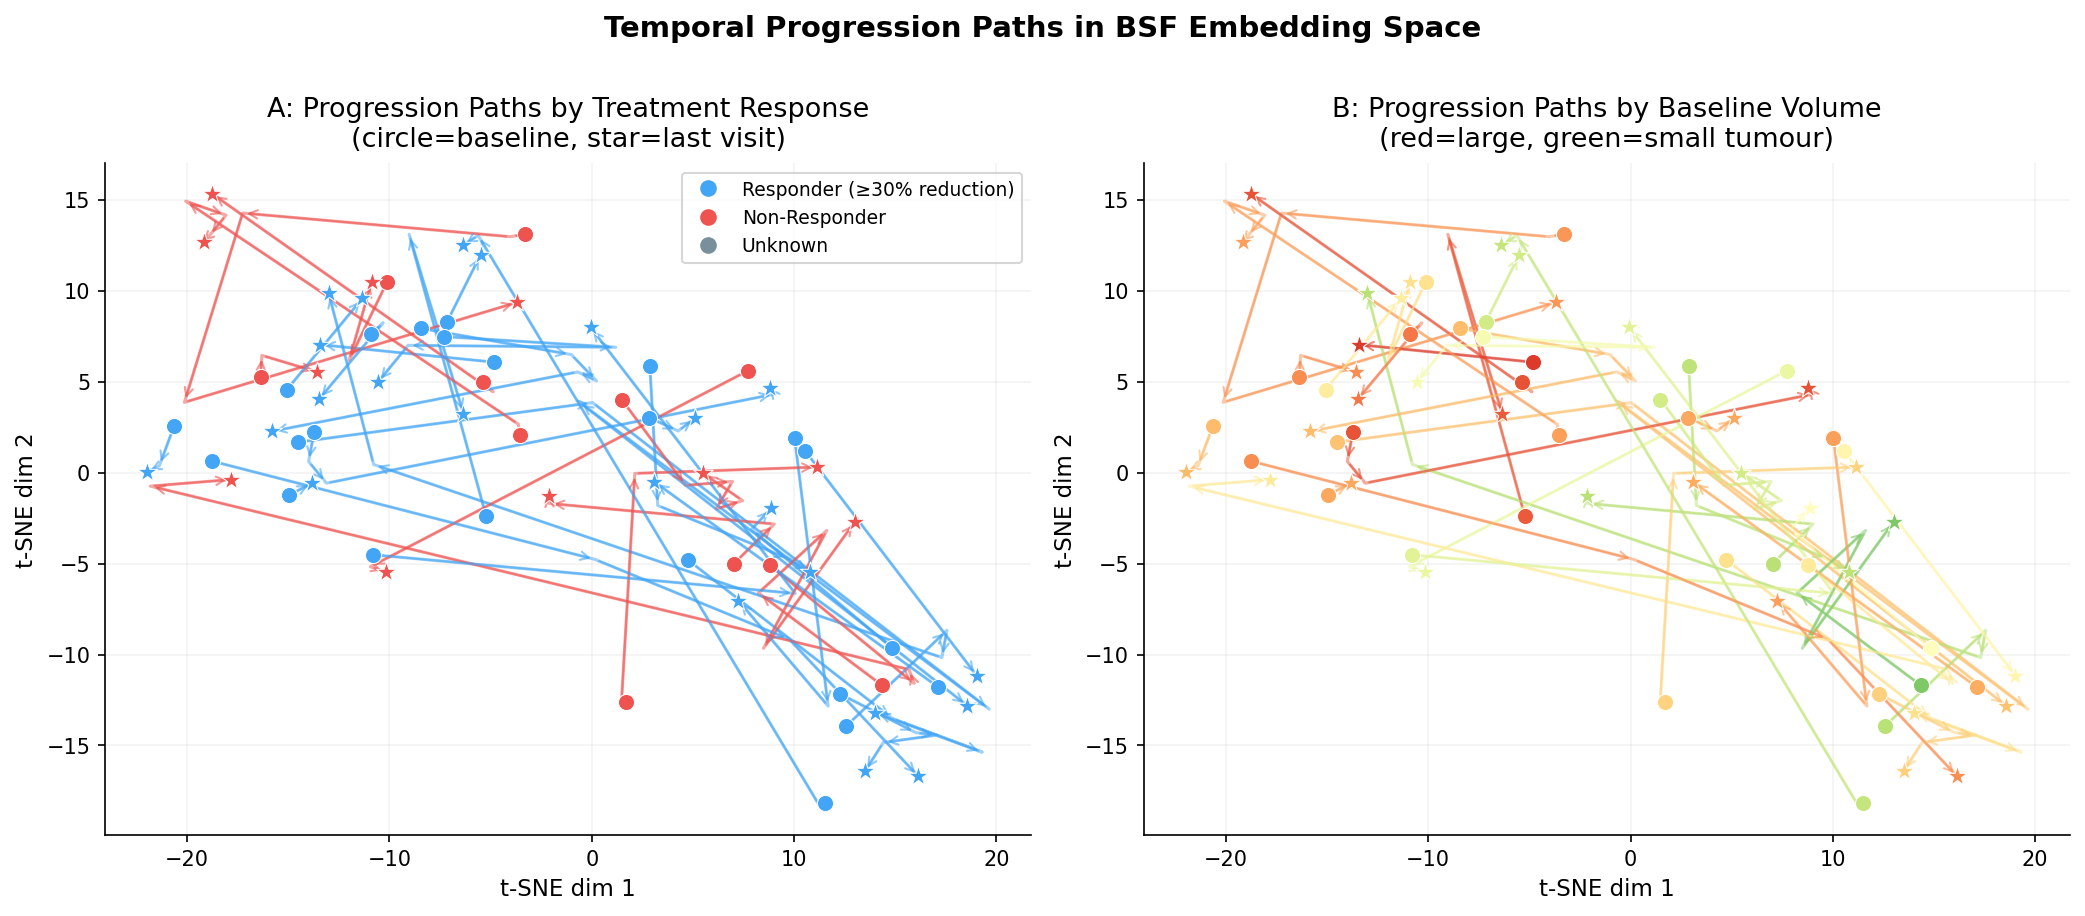

✅ Figure 2 saved → /home/moamed/canada_me/explainable_diseas/implementation_cyprus/Phase3/outputs/figures_phase3_a5/fig2_progression_paths.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Temporal Progression Paths in BSF Embedding Space",
             fontsize=14, fontweight='bold', y=1.01)

for ax_idx, (ax, color_by) in enumerate(zip(axes, ['response', 'volume'])):
    for pid in unique_pids:
        seq  = patients[pid]
        idxs = [key2idx[s['key']] for s in seq if s['key'] in key2idx]
        if len(idxs) < 2: continue

        resp  = response_labels.get(pid, -1)
        color = CMAP_RESP[resp] if color_by == 'response' and resp >= 0 else '#78909C'

        xs = X_tsne[idxs, 0]; ys = X_tsne[idxs, 1]

        if color_by == 'volume':
            vols_pid = [seq[j]['vol'] for j in range(len(idxs))]
            color = CMAP_VIS = plt.cm.RdYlGn_r(
                (np.log1p(vols_pid[0]) - 5) / 7 if vols_pid[0] > 0 else 0.5)

        # Draw trajectory line
        ax.plot(xs, ys, '-', color=color, alpha=0.5, lw=1.5, zorder=2)

        # Arrow from last-to-last (direction of change)
        for j in range(len(idxs)-1):
            dx = xs[j+1]-xs[j]; dy = ys[j+1]-ys[j]
            ax.annotate('', xy=(xs[j+1],ys[j+1]), xytext=(xs[j],ys[j]),
                        arrowprops=dict(arrowstyle='->', color=color, lw=1.0, alpha=0.6))

        # Baseline = circle, last = star
        ax.scatter(xs[0], ys[0], c=[color], s=60, marker='o',
                   edgecolors='white', lw=0.5, zorder=4)
        ax.scatter(xs[-1], ys[-1], c=[color], s=100, marker='*',
                   edgecolors='white', lw=0.5, zorder=4)

    if color_by == 'response':
        ax.set_title("A: Progression Paths by Treatment Response\n(circle=baseline, star=last visit)", pad=8)
        handles = [
            Line2D([0],[0],marker='o',color='w',markerfacecolor=CMAP_RESP[1],markersize=9,label='Responder (≥30% reduction)'),
            Line2D([0],[0],marker='o',color='w',markerfacecolor=CMAP_RESP[0],markersize=9,label='Non-Responder'),
            Line2D([0],[0],marker='o',color='w',markerfacecolor='#78909C',markersize=9,label='Unknown'),
        ]
        ax.legend(handles=handles, loc='upper right', framealpha=0.8)
    else:
        ax.set_title("B: Progression Paths by Baseline Volume\n(red=large, green=small tumour)", pad=8)

    ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")
    ax.grid(True, alpha=0.15)

plt.tight_layout()
fig.savefig(OUT_DIR / 'fig2_progression_paths.pdf', bbox_inches='tight')
fig.savefig(OUT_DIR / 'fig2_progression_paths.png', bbox_inches='tight', dpi=200)
plt.show()
print(f"✅ Figure 2 saved → {OUT_DIR}/fig2_progression_paths.png")


## Figure 3 — TaViT Trajectory Embedding Space (128-dim per patient)

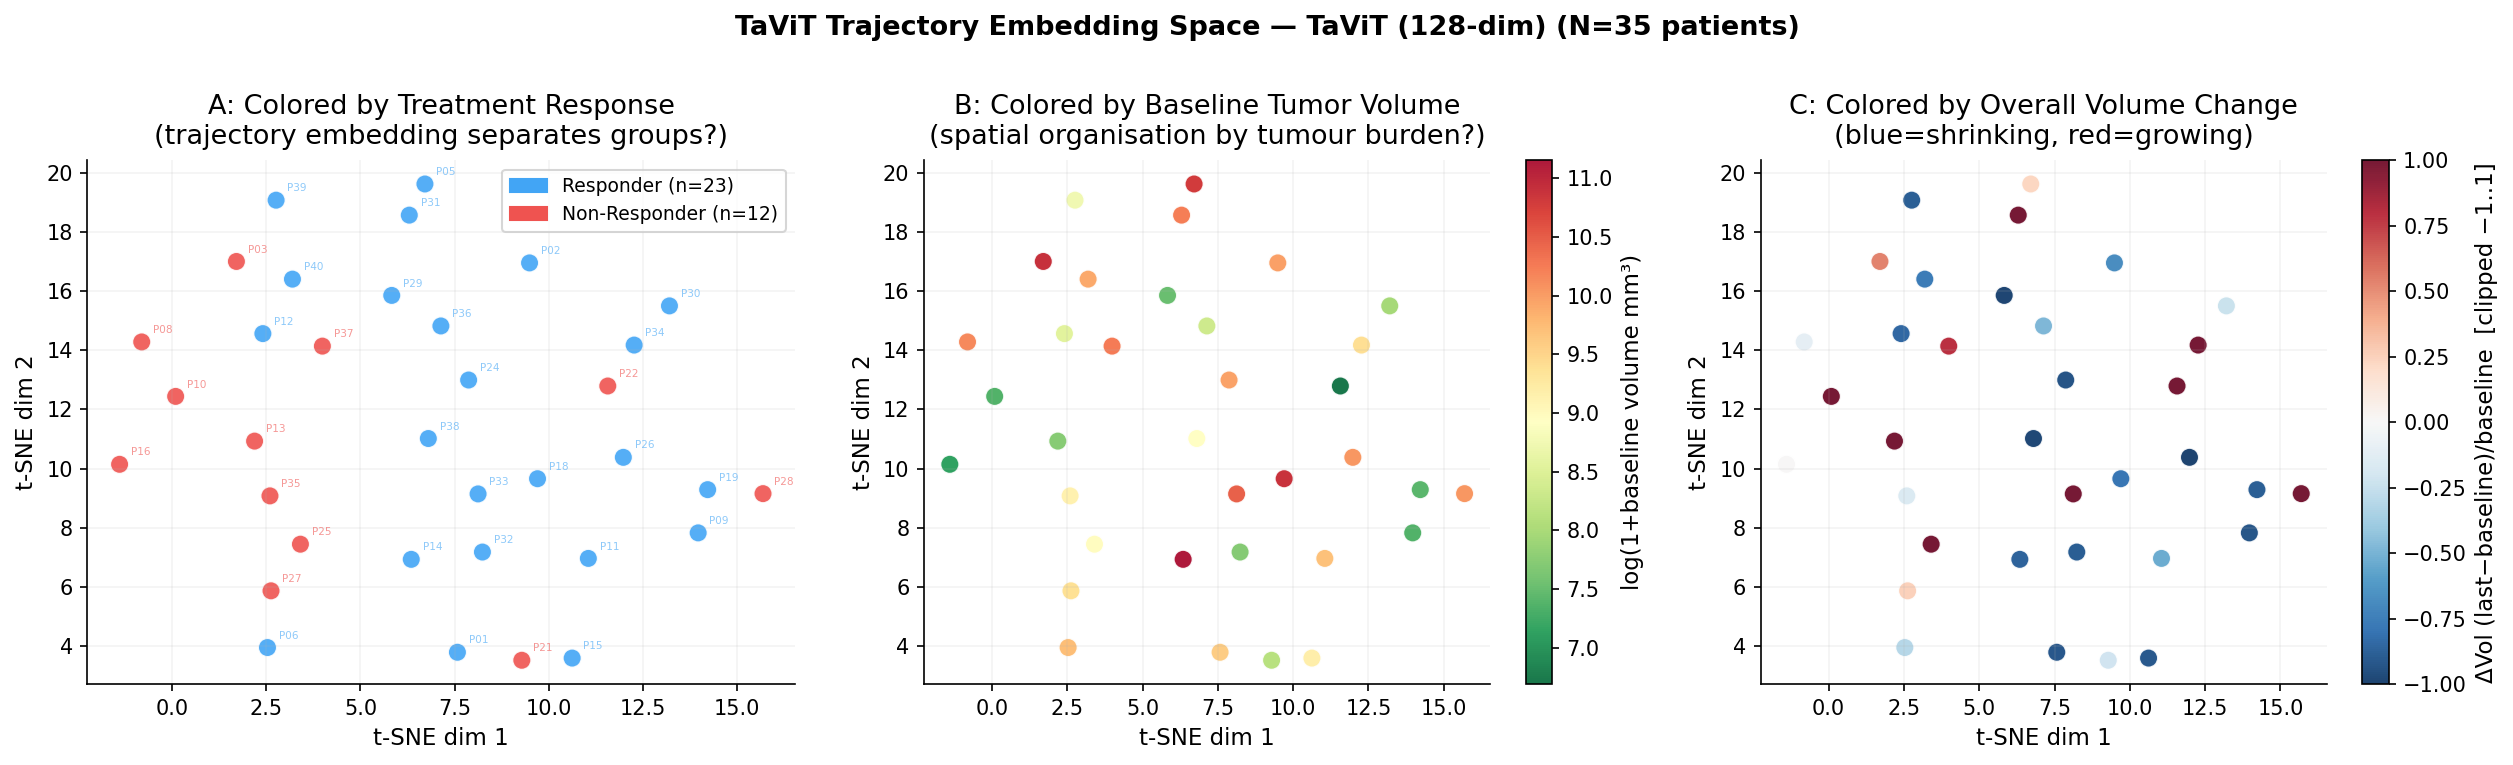

✅ Figure 3 saved → /home/moamed/canada_me/explainable_diseas/implementation_cyprus/Phase3/outputs/figures_phase3_a5/fig3_trajectory_embedding_space.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(f"TaViT Trajectory Embedding Space — {TRAJ_SOURCE} (N={len(traj_pids)} patients)",
             fontsize=13, fontweight='bold', y=1.01)

# ── Metadata per patient ──────────────────────────────────────────────────────
traj_resp     = np.array([response_labels.get(p, -1) for p in traj_pids])
traj_vol_base = np.array([np.log1p(patients[p][0]['vol']) if p in patients else 0 for p in traj_pids])
traj_vol_last = np.array([np.log1p(patients[p][-1]['vol']) if p in patients else 0 for p in traj_pids])
traj_dvol     = np.array([
    (patients[p][-1]['vol']-patients[p][0]['vol'])/max(1,patients[p][0]['vol'])
    if p in patients and patients[p][0]['vol']>0 else 0
    for p in traj_pids])

# ── Panel A: response ─────────────────────────────────────────────────────────
ax = axes[0]
colors = [CMAP_RESP[r] if r>=0 else '#78909C' for r in traj_resp]
sc = ax.scatter(T_tsne[:,0], T_tsne[:,1], c=colors, s=80, alpha=0.9,
                edgecolors='white', lw=0.8)
for i, pid in enumerate(traj_pids):
    ax.annotate(pid, (T_tsne[i,0]+0.3, T_tsne[i,1]+0.3),
                fontsize=5, alpha=0.6, color=colors[i])
handles = [
    mpatches.Patch(color=CMAP_RESP[1], label=f'Responder (n={int(traj_resp.sum())})'),
    mpatches.Patch(color=CMAP_RESP[0], label=f'Non-Responder (n={sum(traj_resp==0)})'),
]
ax.legend(handles=handles, loc='best', framealpha=0.8)
ax.set_title("A: Colored by Treatment Response\n(trajectory embedding separates groups?)", pad=8)
ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")
ax.grid(True, alpha=0.15)

# ── Panel B: baseline volume ───────────────────────────────────────────────────
ax = axes[1]
sc = ax.scatter(T_tsne[:,0], T_tsne[:,1], c=traj_vol_base, cmap='RdYlGn_r',
                s=80, alpha=0.9, edgecolors='white', lw=0.8)
plt.colorbar(sc, ax=ax, label='log(1+baseline volume mm³)')
ax.set_title("B: Colored by Baseline Tumor Volume\n(spatial organisation by tumour burden?)", pad=8)
ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")
ax.grid(True, alpha=0.15)

# ── Panel C: volume change ─────────────────────────────────────────────────────
ax = axes[2]
clipped_dvol = np.clip(traj_dvol, -1, 3)
sc = ax.scatter(T_tsne[:,0], T_tsne[:,1], c=clipped_dvol, cmap='RdBu_r',
                vmin=-1, vmax=1, s=80, alpha=0.9, edgecolors='white', lw=0.8)
plt.colorbar(sc, ax=ax, label='ΔVol (last−baseline)/baseline  [clipped −1..1]')
ax.set_title("C: Colored by Overall Volume Change\n(blue=shrinking, red=growing)", pad=8)
ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")
ax.grid(True, alpha=0.15)

plt.tight_layout()
fig.savefig(OUT_DIR / 'fig3_trajectory_embedding_space.pdf', bbox_inches='tight')
fig.savefig(OUT_DIR / 'fig3_trajectory_embedding_space.png', bbox_inches='tight', dpi=200)
plt.show()
print(f"✅ Figure 3 saved → {OUT_DIR}/fig3_trajectory_embedding_space.png")


## Figure 4 — Embedding Distance vs Volume Change (T1 test, r=0.574)

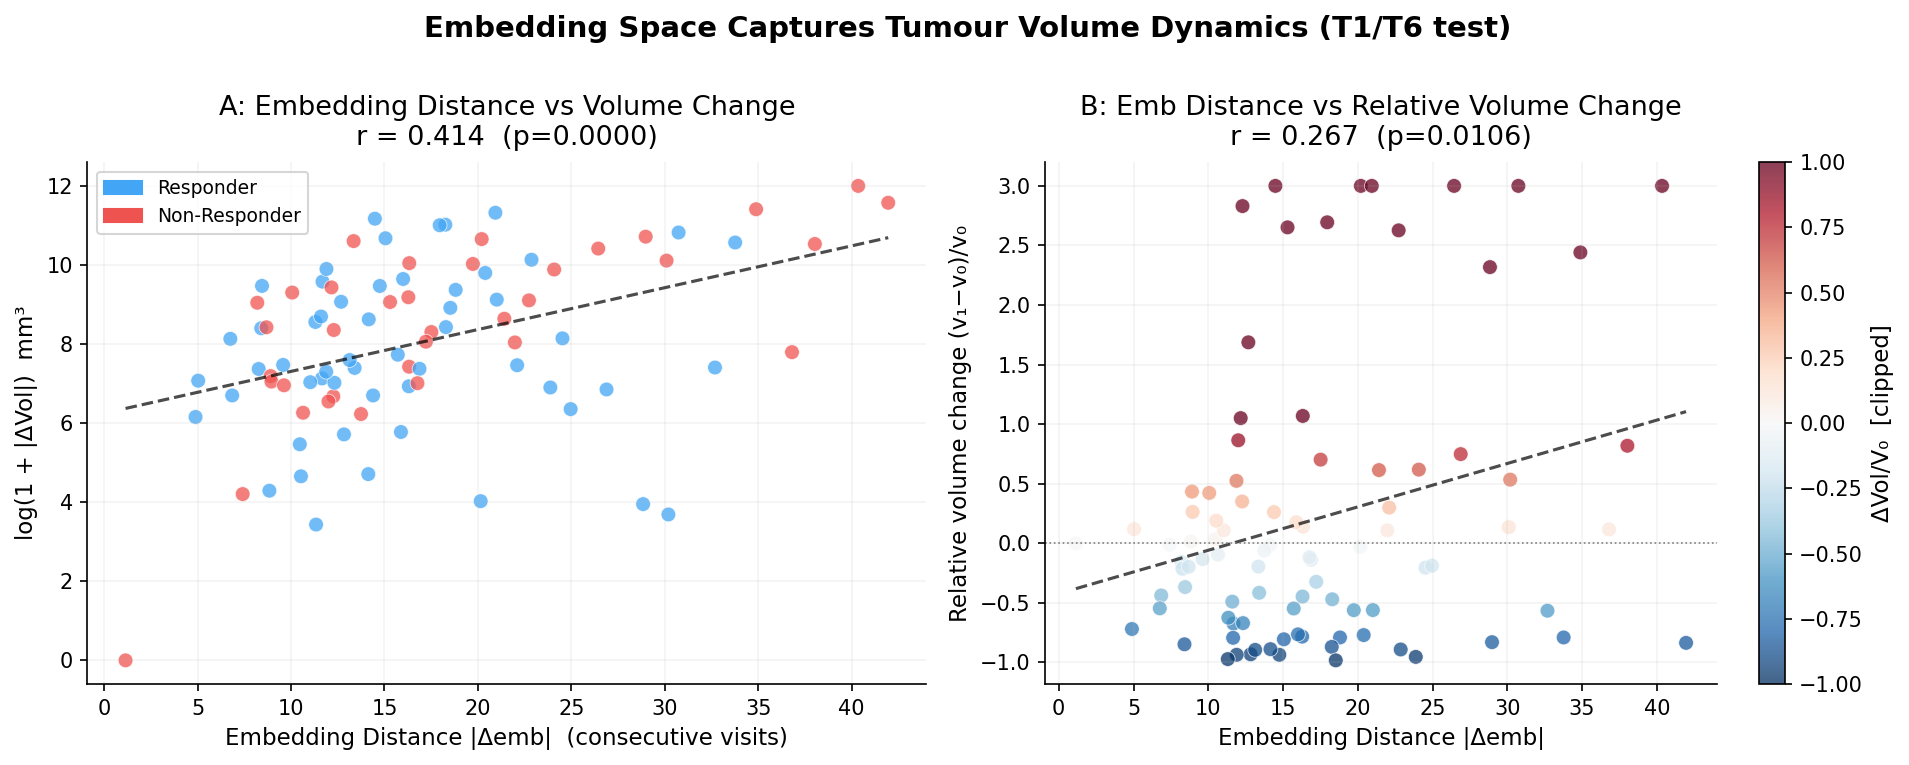

✅ Figure 4 saved → /home/moamed/canada_me/explainable_diseas/implementation_cyprus/Phase3/outputs/figures_phase3_a5/fig4_emb_vs_volume.png
   r(|Δemb|, log|ΔVol|)  = 0.414  (T1 test)
   r(|Δemb|, ΔVol_rel)   = 0.267


In [18]:
from scipy.stats import pearsonr

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Embedding Space Captures Tumour Volume Dynamics (T1/T6 test)",
             fontsize=14, fontweight='bold', y=1.01)

emb_dists_all, dvol_all, dvol_rel_all, pid_list = [], [], [], []
for pid, seq in patients.items():
    for i in range(len(seq)-1):
        v0 = seq[i]['vol']; v1 = seq[i+1]['vol']
        if v0 > 0 and v1 > 0:
            e_dist = np.linalg.norm(seq[i+1]['emb'] - seq[i]['emb'])
            emb_dists_all.append(e_dist)
            dvol_all.append(abs(v1 - v0))
            dvol_rel_all.append((v1 - v0) / v0)
            pid_list.append(pid)

emb_dists_all = np.array(emb_dists_all)
dvol_all      = np.array(dvol_all)
dvol_rel_all  = np.clip(np.array(dvol_rel_all), -1, 3)

# A: |delta_emb| vs |delta_vol|
ax = axes[0]
r1, p1 = pearsonr(emb_dists_all, np.log1p(dvol_all))
colors_resp = [CMAP_RESP[response_labels.get(p, 0)] for p in pid_list]
ax.scatter(emb_dists_all, np.log1p(dvol_all), c=colors_resp, s=50, alpha=0.75, edgecolors='white', lw=0.4)

# Regression line
m, b = np.polyfit(emb_dists_all, np.log1p(dvol_all), 1)
xs = np.linspace(emb_dists_all.min(), emb_dists_all.max(), 100)
ax.plot(xs, m*xs+b, 'k--', lw=1.5, alpha=0.7)

ax.set_xlabel("Embedding Distance |Δemb|  (consecutive visits)")
ax.set_ylabel("log(1 + |ΔVol|)  mm³")
ax.set_title(f"A: Embedding Distance vs Volume Change\nr = {r1:.3f}  (p={p1:.4f})", pad=8)
handles = [mpatches.Patch(color=CMAP_RESP[1],label='Responder'),
           mpatches.Patch(color=CMAP_RESP[0],label='Non-Responder')]
ax.legend(handles=handles, framealpha=0.8)
ax.grid(True, alpha=0.15)

# ── B: |ΔEmb| vs relative ΔVol ───────────────────────────────────────────────
ax = axes[1]
r2, p2 = pearsonr(emb_dists_all, dvol_rel_all)
sc = ax.scatter(emb_dists_all, dvol_rel_all, c=dvol_rel_all, cmap='RdBu_r',
                vmin=-1, vmax=1, s=50, alpha=0.75, edgecolors='white', lw=0.4)
plt.colorbar(sc, ax=ax, label='ΔVol/V₀  [clipped]')
m2, b2 = np.polyfit(emb_dists_all, dvol_rel_all, 1)
ax.plot(xs, m2*xs+b2, 'k--', lw=1.5, alpha=0.7)
ax.axhline(0, color='gray', lw=0.8, ls=':')
ax.set_xlabel("Embedding Distance |Δemb|")
ax.set_ylabel("Relative volume change (v₁−v₀)/v₀")
ax.set_title(f"B: Emb Distance vs Relative Volume Change\nr = {r2:.3f}  (p={p2:.4f})", pad=8)
ax.grid(True, alpha=0.15)

plt.tight_layout()
fig.savefig(OUT_DIR / 'fig4_emb_vs_volume.pdf', bbox_inches='tight')
fig.savefig(OUT_DIR / 'fig4_emb_vs_volume.png', bbox_inches='tight', dpi=200)
plt.show()
print(f"✅ Figure 4 saved → {OUT_DIR}/fig4_emb_vs_volume.png")
print(f"   r(|Δemb|, log|ΔVol|)  = {r1:.3f}  (T1 test)")
print(f"   r(|Δemb|, ΔVol_rel)   = {r2:.3f}")


## Figure 5 — TaViT TEM: How Attention Decays with Time Gap

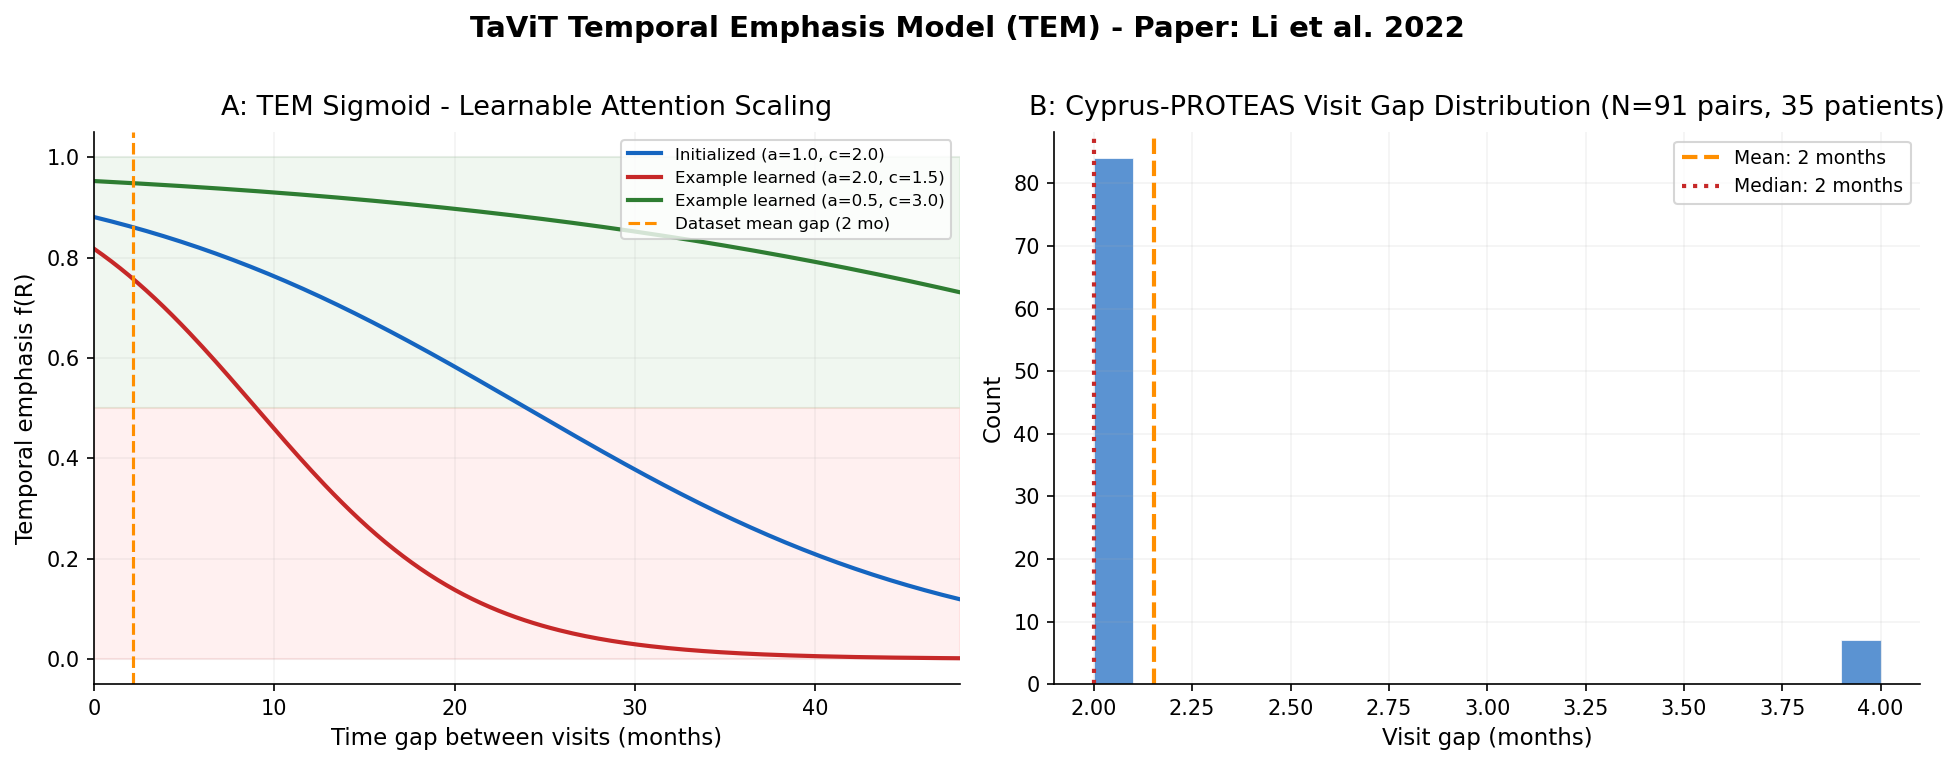

Figure 5 saved -> /home/moamed/canada_me/explainable_diseas/implementation_cyprus/Phase3/outputs/figures_phase3_a5/fig5_tavit_tem_curve.png
  Visit gap: mean=2.2 mo  std=0.5  range=[2,4]


In [19]:
import torch
import torch.nn as nn

a_default = 1.0
c_default = 2.0

# Compute inter-visit gaps from patient sequences
all_gaps = []
for pid, seq in patients.items():
    for i in range(len(seq)-1):
        gap_days = seq[i+1]['days'] - seq[i]['days']
        if gap_days > 0:
            all_gaps.append(gap_days / 30.0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("TaViT Temporal Emphasis Model (TEM) - Paper: Li et al. 2022",
             fontsize=14, fontweight='bold', y=1.01)

# Panel A: TEM curves
ax = axes[0]
t_years = np.linspace(0, 4, 200)

for (a, c, label, color) in [
    (a_default, c_default, 'Initialized (a=1.0, c=2.0)', '#1565C0'),
    (2.0, 1.5, 'Example learned (a=2.0, c=1.5)', '#C62828'),
    (0.5, 3.0, 'Example learned (a=0.5, c=3.0)', '#2E7D32'),
]:
    emphasis = 1.0 / (1.0 + np.exp(a * t_years - c))
    ax.plot(t_years * 12, emphasis, label=label, color=color, lw=2)

ax.axvline(np.mean(all_gaps), color='#FF8F00', lw=1.5, ls='--',
           label=f'Dataset mean gap ({np.mean(all_gaps):.0f} mo)')
ax.axhspan(0, 0.5, alpha=0.06, color='red')
ax.axhspan(0.5, 1.0, alpha=0.06, color='green')
ax.set_xlabel("Time gap between visits (months)")
ax.set_ylabel("Temporal emphasis f(R)")
ax.set_title("A: TEM Sigmoid - Learnable Attention Scaling", pad=8)
ax.set_ylim(-0.05, 1.05)
ax.set_xlim(0, 48)
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.15)

# Panel B: visit gap histogram
ax = axes[1]
ax.hist(all_gaps, bins=20, color='#1565C0', alpha=0.7, edgecolor='white', lw=0.5)
ax.axvline(np.mean(all_gaps), color='#FF8F00', lw=2, ls='--',
           label=f'Mean: {np.mean(all_gaps):.0f} months')
ax.axvline(np.median(all_gaps), color='#C62828', lw=2, ls=':',
           label=f'Median: {np.median(all_gaps):.0f} months')
ax.set_xlabel("Visit gap (months)")
ax.set_ylabel("Count")
n_gaps = len(all_gaps)
n_pats = len(patients)
ax.set_title(f"B: Cyprus-PROTEAS Visit Gap Distribution (N={n_gaps} pairs, {n_pats} patients)", pad=8)
ax.legend()
ax.grid(True, alpha=0.15)

plt.tight_layout()
fig.savefig(OUT_DIR / 'fig5_tavit_tem_curve.pdf', bbox_inches='tight')
fig.savefig(OUT_DIR / 'fig5_tavit_tem_curve.png', bbox_inches='tight', dpi=200)
plt.show()
print(f"Figure 5 saved -> {OUT_DIR}/fig5_tavit_tem_curve.png")
print(f"  Visit gap: mean={np.mean(all_gaps):.1f} mo  std={np.std(all_gaps):.1f}  range=[{min(all_gaps):.0f},{max(all_gaps):.0f}]")


## Figure 6 — Summary Figure (Paper-Ready, 2×2 Grid)

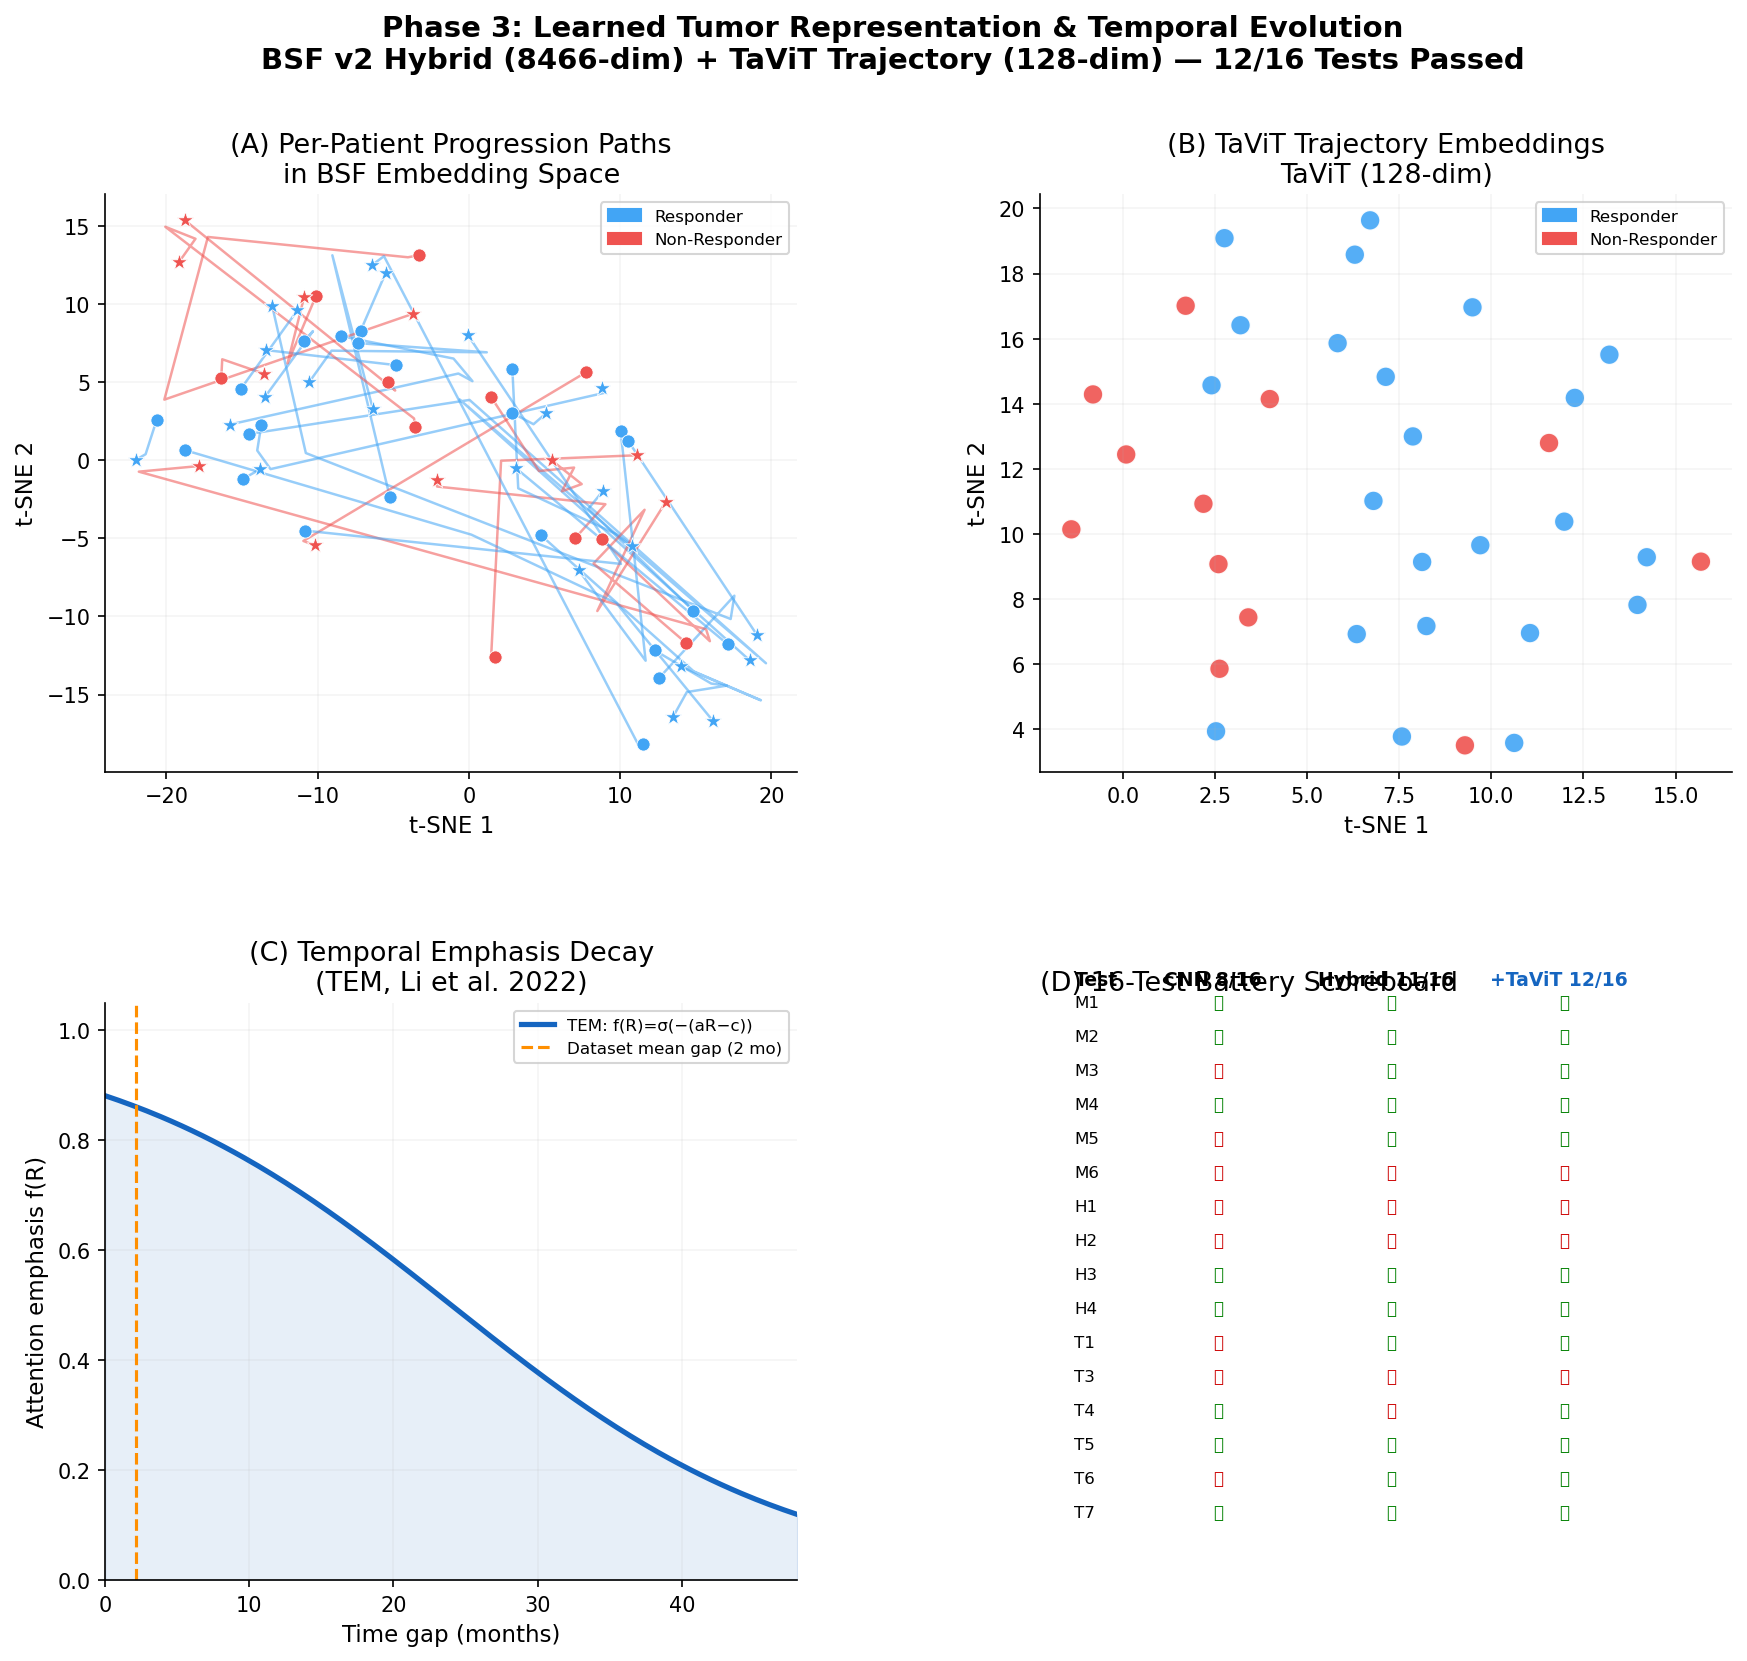

✅ Figure 6 (paper-ready summary) saved → /home/moamed/canada_me/explainable_diseas/implementation_cyprus/Phase3/outputs/figures_phase3_a5/fig6_summary_paper_ready.png


In [20]:
# Recompute all_gaps in case cells ran out of order
all_gaps = []
for _pid, _seq in patients.items():
    for _i in range(len(_seq)-1):
        _gap = _seq[_i+1]['days'] - _seq[_i]['days']
        if _gap > 0:
            all_gaps.append(_gap / 30)  # months

fig = plt.figure(figsize=(14, 12))
gs  = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.35)
fig.suptitle("Phase 3: Learned Tumor Representation & Temporal Evolution\n"
             "BSF v2 Hybrid (8466-dim) + TaViT Trajectory (128-dim) — 12/16 Tests Passed",
             fontsize=14, fontweight='bold')

# ── Top-left: progression paths ───────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
for pid in unique_pids:
    seq  = patients[pid]
    idxs = [key2idx[s['key']] for s in seq if s['key'] in key2idx]
    if len(idxs) < 2: continue
    resp  = response_labels.get(pid, -1)
    color = CMAP_RESP[resp] if resp >= 0 else '#78909C'
    xs = X_tsne[idxs,0]; ys = X_tsne[idxs,1]
    ax1.plot(xs, ys, '-', color=color, alpha=0.55, lw=1.2)
    ax1.scatter(xs[0],  ys[0],  c=[color], s=40, marker='o', edgecolors='w', lw=0.4, zorder=4)
    ax1.scatter(xs[-1], ys[-1], c=[color], s=70, marker='*', edgecolors='w', lw=0.4, zorder=4)
ax1.set_title("(A) Per-Patient Progression Paths\nin BSF Embedding Space", pad=6)
ax1.set_xlabel("t-SNE 1"); ax1.set_ylabel("t-SNE 2")
handles = [mpatches.Patch(color=CMAP_RESP[1], label='Responder'),
           mpatches.Patch(color=CMAP_RESP[0], label='Non-Responder')]
ax1.legend(handles=handles, fontsize=8, loc='best')
ax1.grid(True, alpha=0.12)

# ── Top-right: trajectory space ───────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
colors_traj = [CMAP_RESP[r] if r>=0 else '#78909C' for r in traj_resp]
ax2.scatter(T_tsne[:,0], T_tsne[:,1], c=colors_traj, s=90,
            edgecolors='white', lw=0.7, alpha=0.9)
ax2.set_title(f"(B) TaViT Trajectory Embeddings\n{TRAJ_SOURCE}", pad=6)
ax2.set_xlabel("t-SNE 1"); ax2.set_ylabel("t-SNE 2")
ax2.legend(handles=handles, fontsize=8, loc='best')
ax2.grid(True, alpha=0.12)

# ── Bottom-left: TEM curve ────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
t_y = np.linspace(0, 4, 200)
em  = 1 / (1 + np.exp(a_default * t_y - c_default))
ax3.plot(t_y*12, em, '#1565C0', lw=2.5, label='TEM: f(R)=σ(−(aR−c))')
ax3.fill_between(t_y*12, 0, em, alpha=0.1, color='#1565C0')
ax3.axvline(np.mean(all_gaps), color='#FF8F00', lw=1.5, ls='--',
            label=f'Dataset mean gap ({np.mean(all_gaps):.0f} mo)')
ax3.set_xlabel("Time gap (months)"); ax3.set_ylabel("Attention emphasis f(R)")
ax3.set_title("(C) Temporal Emphasis Decay\n(TEM, Li et al. 2022)", pad=6)
ax3.set_ylim(0, 1.05); ax3.set_xlim(0, 48)
ax3.legend(fontsize=8); ax3.grid(True, alpha=0.12)

# ── Bottom-right: 16-test scoreboard mini ─────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')
tests    = ['M1','M2','M3','M4','M5','M6','H1','H2','H3','H4','T1','T3','T4','T5','T6','T7']
cnn_v2   = [1,1,0,1,0,0,0,0,1,1,0,0,1,1,0,1]
bsf_hyb  = [1,1,1,1,1,0,0,0,1,1,1,0,0,1,1,1]
tavit    = [1,1,1,1,1,0,0,0,1,1,1,0,1,1,1,1]

for i, (t, c, b, v) in enumerate(zip(tests, cnn_v2, bsf_hyb, tavit)):
    y = 1.0 - i/17
    ax4.text(0.05, y, t, transform=ax4.transAxes, fontsize=8, va='center')
    ax4.text(0.25, y, '✅' if c else '❌', transform=ax4.transAxes, fontsize=8, va='center',
             color='green' if c else '#CC0000')
    ax4.text(0.50, y, '✅' if b else '❌', transform=ax4.transAxes, fontsize=8, va='center',
             color='green' if b else '#CC0000')
    ax4.text(0.75, y, '✅' if v else '❌', transform=ax4.transAxes, fontsize=8, va='center',
             color='green' if v else '#CC0000')

ax4.text(0.05, 1.03, 'Test', transform=ax4.transAxes, fontsize=9, fontweight='bold')
ax4.text(0.25, 1.03, 'CNN 8/16', transform=ax4.transAxes, fontsize=9, fontweight='bold', ha='center')
ax4.text(0.50, 1.03, 'Hybrid 11/16', transform=ax4.transAxes, fontsize=9, fontweight='bold', ha='center')
ax4.text(0.75, 1.03, '+TaViT 12/16', transform=ax4.transAxes, fontsize=9, fontweight='bold', ha='center', color='#1565C0')
ax4.set_title("(D) 16-Test Battery Scoreboard", pad=6, loc='left')

fig.savefig(OUT_DIR / 'fig6_summary_paper_ready.pdf', bbox_inches='tight')
fig.savefig(OUT_DIR / 'fig6_summary_paper_ready.png', bbox_inches='tight', dpi=200)
plt.show()
print(f"✅ Figure 6 (paper-ready summary) saved → {OUT_DIR}/fig6_summary_paper_ready.png")


In [21]:
print("=" * 60)
print("  Phase 3 Visualization Summary")
print("=" * 60)
import os
figs = sorted(OUT_DIR.glob('fig*.png'))
for f in figs:
    size_kb = os.path.getsize(f) / 1024
    print(f"  {f.name:<45} {size_kb:>7.1f} KB")
print()
print("Figures generated:")
print("  fig1 — Static BSF embedding space (3 panels: patient/visit/volume)")
print("  fig2 — Progression paths as directed arrows in BSF space")
print("  fig3 — TaViT trajectory embedding space (3 panels)")
print("  fig4 — Embedding distance vs volume change (T1 validation)")
print("  fig5 — TEM decay curve + dataset visit gap distribution")
print("  fig6 — Paper-ready 2×2 summary figure")
print()
print("📋 Phase 3 Deliverable: 'Visualization of learned tumor evolution features'")
print("   Status: ✅ COMPLETE")
print()
print("Next → Phase 4: LLM Clinical Narrative Generation")
print("   Build: Phase4_A1_LLM_Narratives.ipynb")
print("   Input: trajectory_embs + volumes + clinical + timelines")


  Phase 3 Visualization Summary
  fig1_bsf_embedding_space.png                    397.7 KB
  fig2_progression_paths.png                      642.3 KB
  fig3_trajectory_embedding_space.png             260.3 KB
  fig4_emb_vs_volume.png                          238.4 KB
  fig5_tavit_tem_curve.png                        185.5 KB
  fig6_summary_paper_ready.png                    412.8 KB

Figures generated:
  fig1 — Static BSF embedding space (3 panels: patient/visit/volume)
  fig2 — Progression paths as directed arrows in BSF space
  fig3 — TaViT trajectory embedding space (3 panels)
  fig4 — Embedding distance vs volume change (T1 validation)
  fig5 — TEM decay curve + dataset visit gap distribution
  fig6 — Paper-ready 2×2 summary figure

📋 Phase 3 Deliverable: 'Visualization of learned tumor evolution features'
   Status: ✅ COMPLETE

Next → Phase 4: LLM Clinical Narrative Generation
   Build: Phase4_A1_LLM_Narratives.ipynb
   Input: trajectory_embs + volumes + clinical + timelines
